# Sesión 03 — Sistemas OFDM e Implementación
### Laboratorio Python · Sistemas de Comunicaciones Inalámbricas

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ollerenac/wireless-communication-systems/blob/main/docs/sessions/03-ofdm-systems/lab.ipynb)

## Objetivos del Laboratorio

1. Visualizar la estructura temporal y espectral de un símbolo OFDM
2. Verificar que la cadena IFFT → canal → FFT recupera los símbolos perfectamente cuando el canal es plano
3. Demostrar experimentalmente que sin CP aparece ISI e ICI, y que el CP las elimina
4. Implementar los ecualizadores ZF y MMSE y comparar su BER sobre canal frequency-selective
5. Medir la BER de OFDM sobre canal multipath y compararla con la de AWGN puro

In [61]:
%pip install numpy scipy matplotlib --quiet

import os
import numpy as np
from scipy.special import erfc
import matplotlib.pyplot as plt

os.makedirs('figures', exist_ok=True)

%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

rng = np.random.default_rng(seed=0)
print('Setup completado.')

Setup completado.


## Repaso Teórico

### Cadena OFDM completa

```
TX: Bits → QAM mapper → [X_0, X_1, ..., X_{N-1}] → IFFT → añadir CP → canal h[l] → AWGN
RX: → eliminar CP → FFT → [Y_0, Y_1, ..., Y_{N-1}] → ecualizador H[k] → QAM demod → Bits
```

**Señal OFDM en tiempo:**
$$x[n] = \frac{1}{\sqrt{N}}\sum_{k=0}^{N-1} X[k]\, e^{j2\pi kn/N}, \quad n = 0, \ldots, N-1 \tag{2}$$

**Tras eliminar CP y aplicar FFT con canal circular:**
$$Y[k] = H[k]\cdot X[k] + W[k] \tag{5}$$

donde $H[k] = \sum_l h[l]\, e^{-j2\pi kl/N}$ es la DFT del canal.

**Ecualizador ZF:**
$$\hat{X}^{ZF}[k] = \frac{Y[k]}{H[k]} \tag{6}$$

**Ecualizador MMSE:**
$$\hat{X}^{MMSE}[k] = \frac{H^*[k]}{|H[k]|^2 + 1/\text{SNR}}\cdot Y[k] \tag{8}$$

### Parámetros del sistema para este laboratorio

| Parámetro | Valor |
|-----------|-------|
| $N$ (subportadoras) | 64 |
| $N_{CP}$ (CP) | 16 muestras |
| Modulación | QPSK ($M=4$) |
| Canal | multipath (configurable) |

---
## Parámetros Globales del Sistema

In [62]:
# Parámetros OFDM
N    = 64    # número de subportadoras
N_CP = 16   # longitud del prefijo cíclico
M    = 4    # orden de modulación (QPSK)
k    = int(np.log2(M))  # bits por símbolo

# Canal multipath de referencia: 3 caminos
h_channel = np.array([0.8, 0.0, 0.0, 0.5, 0.0, 0.0, 0.3])  # longitud L=7
h_channel = h_channel / np.linalg.norm(h_channel)            # normalizar energía
L = len(h_channel)

print(f'Parámetros OFDM: N={N}, N_CP={N_CP}, M={M} ({k} bits/símbolo)')
print(f'Canal: {L} caminos, energía normalizada')
print(f'Overhead CP: {N_CP/(N+N_CP)*100:.1f}%')
print(f'Condición CP: N_CP={N_CP} >= L-1={L-1}: {N_CP >= L-1}')

Parámetros OFDM: N=64, N_CP=16, M=4 (2 bits/símbolo)
Canal: 7 caminos, energía normalizada
Overhead CP: 20.0%
Condición CP: N_CP=16 >= L-1=6: True


---
## Sección 1 — Construcción Bloque a Bloque

Antes de los ejercicios de integración, construiremos cada bloque del transceptor OFDM en **aislamiento**: definimos la función, la probamos con una entrada mínima y verificamos su salida. Cuando llegues a la Sección 2, todas estas funciones ya estarán disponibles en memoria.

| Bloque | Función Python | Entrada → Salida |
|--------|---------------|-----------------|
| 1 | `qpsk_map` | bits → símbolos QPSK |
| 2 | `ofdm_tx` | $X[k]$ → $x[n]$ con CP |
| 3 | `apply_channel` | $x[n]$ → $y[n]$ |
| 4 | `ofdm_rx_no_channel` | $y[n]$ → $Y[k]$ |
| 5 | `zf_equalizer` | $Y[k]$ → $\hat{X}^{ZF}[k]$ |
| 6 | `mmse_equalizer` | $Y[k]$ → $\hat{X}^{MMSE}[k]$ |
| 7 | `ls_channel_estimate` | pilotos → $\hat{H}[k]$ |
| 8 | `qpsk_demap` | $\hat{X}[k]$ → bits |
| 9 | `ofdm_ber_quick` | cadena completa → BER |

### Bloque 1 — QAM Mapper (QPSK)

**Entrada:** vector de bits &nbsp;→&nbsp; **Operación:** agrupación de 2 bits + codificación Gray &nbsp;→&nbsp; **Salida:** símbolo complejo $s = (I + jQ)/\sqrt{2}$ con energía media $|s|^2 = 1$

La codificación Gray garantiza que puntos vecinos en la constelación difieran en 1 solo bit, minimizando la BER en detección con errores pequeños.

Bits   → Símbolo QPSK (I + jQ)         |s|
  00  → +0.7071 + +0.7071j     1.0000
  01  → +0.7071 + -0.7071j     1.0000
  11  → -0.7071 + -0.7071j     1.0000
  10  → -0.7071 + +0.7071j     1.0000


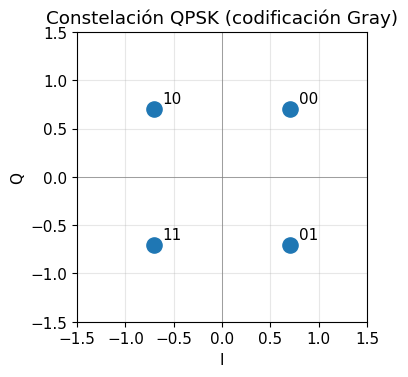

In [63]:
def qpsk_map(bits):
    """Mapeado QPSK Gray: 2 bits → 1 símbolo complejo con |s|²=1."""
    b0, b1 = bits[0::2], bits[1::2]
    I = 1 - 2*b0   # bit 0: 0→+1, 1→−1
    Q = 1 - 2*b1   # bit 1: 0→+1, 1→−1
    return (I + 1j*Q) / np.sqrt(2)

# Test: los 4 patrones posibles de 2 bits
test_bits_b1 = np.array([0,0, 0,1, 1,1, 1,0])
syms_b1 = qpsk_map(test_bits_b1)
print('Bits   → Símbolo QPSK (I + jQ)         |s|')
for i, label in enumerate(['00','01','11','10']):
    s = syms_b1[i]
    print(f'  {label}  → {s.real:+.4f} + {s.imag:+.4f}j     {abs(s):.4f}')

fig, ax = plt.subplots(figsize=(4, 4))
ax.scatter(syms_b1.real, syms_b1.imag, s=120, zorder=5)
for s, lbl in zip(syms_b1, ['00','01','11','10']):
    ax.annotate(lbl, (s.real, s.imag), textcoords='offset points', xytext=(6, 4), fontsize=11)
ax.set_xlim(-1.5, 1.5); ax.set_ylim(-1.5, 1.5)
ax.set_xlabel('I'); ax.set_ylabel('Q')
ax.set_title('Constelación QPSK (codificación Gray)')
ax.set_aspect('equal')
ax.axhline(0, color='gray', lw=0.5); ax.axvline(0, color='gray', lw=0.5)
plt.tight_layout(); plt.show()

### Bloque 2 — Transmisor OFDM (IFFT + Prefijo Cíclico)

**Entrada:** $N$ símbolos en frecuencia $X[k]$ &nbsp;→&nbsp; **Operación:** IFFT normalizada → copia de las últimas $N_{CP}$ muestras al frente &nbsp;→&nbsp; **Salida:** símbolo OFDM de longitud $N + N_{CP}$

La IFFT reparte la energía de las $N$ subportadoras en el tiempo. El CP es la copia que permitirá al receptor convertir la convolución lineal del canal en circular.

Entrada:  64 símbolos QPSK complejos
Salida:   80 muestras (N + N_CP = 64 + 16)
¿CP == cola del símbolo? True


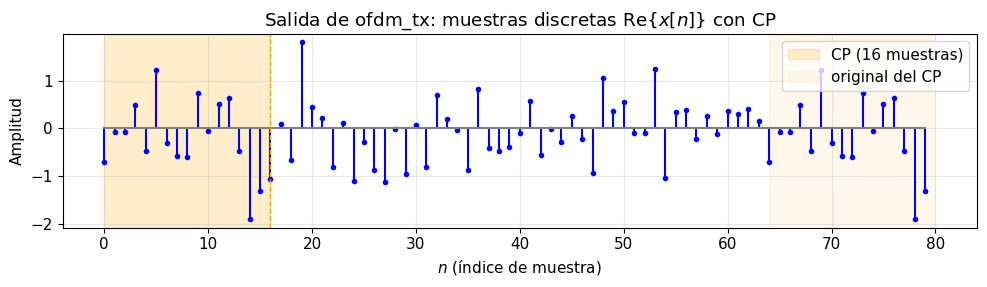

In [64]:
def ofdm_tx(X, N_CP):
    """Genera símbolo OFDM: IFFT normalizada + prefijo cíclico."""
    x  = np.fft.ifft(X, norm='ortho')
    cp = x[-N_CP:]
    return np.concatenate([cp, x])

# Test: generar símbolo OFDM y verificar estructura CP
bits_b2   = rng.integers(0, 2, N * 2)
X_test_b2 = qpsk_map(bits_b2)           # N símbolos QPSK (disponibles en bloques 3–8)
x_cp_b2   = ofdm_tx(X_test_b2, N_CP)   # símbolo OFDM con CP (disponible en bloques 3–8)

print(f'Entrada:  {N} símbolos QPSK complejos')
print(f'Salida:   {len(x_cp_b2)} muestras (N + N_CP = {N} + {N_CP})')
print(f'¿CP == cola del símbolo? {np.allclose(x_cp_b2[:N_CP], x_cp_b2[N_CP+N-N_CP:])}')

# Stem plot: x[n] es una secuencia discreta (salida de la IFFT), no una señal continua.
# El DAC es el bloque que luego interpola entre estas muestras.
fig, ax = plt.subplots(figsize=(10, 3))
t = np.arange(len(x_cp_b2))
ax.stem(t, x_cp_b2.real, linefmt='b-', markerfmt='b.', basefmt='gray')
ax.axvspan(0, N_CP, alpha=0.2, color='orange', label=f'CP ({N_CP} muestras)')
ax.axvspan(N, N+N_CP, alpha=0.08, color='orange', label='original del CP')
ax.axvline(N_CP, color='orange', ls='--', lw=1)
ax.set_xlabel('$n$ (índice de muestra)')
ax.set_ylabel('Amplitud')
ax.set_title('Salida de ofdm_tx: muestras discretas Re{$x[n]$} con CP')
ax.legend(loc='upper right')
plt.tight_layout(); plt.show()

### Bloque 3 — Canal Multipath

**Entrada:** señal $x[n]$ (con CP, longitud $N+N_{CP}$) &nbsp;→&nbsp; **Operación:** convolución lineal $y[n] = (x \ast h)[n]$ &nbsp;→&nbsp; **Salida:** señal recibida $y[n]$ de la misma longitud (el transitorio al final se trunca)

El desafío: la convolución *lineal* mezcla muestras de símbolos consecutivos (ISI). El CP convierte esa convolución lineal en *circular*, eliminando la ISI. Verificaremos eso en el Bloque 4.

> **Nota:** el AWGN no se añade aquí — se introduce en el Bloque 5 para poder observar el efecto del canal y el del ruido por separado. En la cadena real ambas perturbaciones ocurren simultáneamente: $y[n] = (x \ast h)[n] + w[n]$.

h_channel = [0.8081 0.     0.     0.5051 0.     0.     0.303 ]
y[0:L]    = [0.8081 0.     0.     0.5051 0.     0.     0.303 ]
¿Coinciden? True


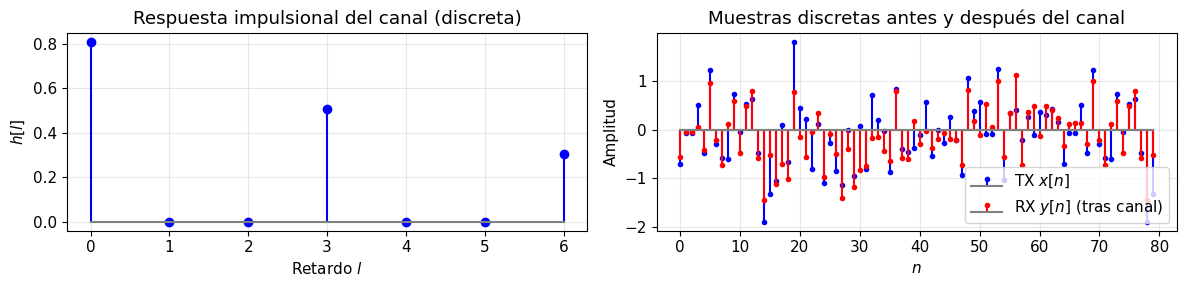

In [65]:
def apply_channel(x_signal, h):
    """Convolución lineal del canal multipath (truncada a la longitud de entrada)."""
    return np.convolve(x_signal, h, mode='full')[:len(x_signal)]

# Test: respuesta al impulso debe reproducir h_channel
impulse_b3   = np.zeros(N + N_CP, dtype=complex); impulse_b3[0] = 1.0
y_impulse_b3 = apply_channel(impulse_b3, h_channel)
print(f'h_channel = {np.round(h_channel, 4)}')
print(f'y[0:L]    = {np.round(y_impulse_b3[:L].real, 4)}')
print(f'¿Coinciden? {np.allclose(y_impulse_b3[:L].real, h_channel)}')

# Aplicar canal al símbolo OFDM de prueba (de Bloque 2)
y_ch_b3 = apply_channel(x_cp_b2, h_channel)[:N + N_CP]   # disponible en Bloque 4

fig, axes = plt.subplots(1, 2, figsize=(12, 3))
axes[0].stem(np.arange(L), h_channel, linefmt='b-', markerfmt='bo', basefmt='gray')
axes[0].set_xlabel('Retardo $l$'); axes[0].set_ylabel('$h[l]$')
axes[0].set_title('Respuesta impulsional del canal (discreta)')

t = np.arange(N + N_CP)
axes[1].stem(t, x_cp_b2.real, linefmt='b-', markerfmt='b.', basefmt='gray', label='TX $x[n]$')
axes[1].stem(t, y_ch_b3.real, linefmt='r-', markerfmt='r.', basefmt='gray', label='RX $y[n]$ (tras canal)')
axes[1].set_xlabel('$n$'); axes[1].set_ylabel('Amplitud')
axes[1].set_title('Muestras discretas antes y después del canal')
axes[1].legend()
plt.tight_layout(); plt.show()

### Bloque 4 — Receptor OFDM (Eliminar CP + FFT)

**Entrada:** señal recibida $y[n]$ de longitud $N + N_{CP}$ &nbsp;→&nbsp; **Operación:** descartar las primeras $N_{CP}$ muestras (el CP ya absorbió el transitorio) + FFT normalizada &nbsp;→&nbsp; **Salida:** $N$ símbolos en frecuencia $Y[k] = H[k]\cdot X[k] + W[k]$

Sin canal, $Y[k] = X[k]$ exactamente (error numérico $\sim 10^{-14}$). Con canal, cada $Y[k]$ aparece rotado y escalado por $H[k]$: por eso se necesita un ecualizador.

Sin canal  | Error máximo |Y[k] - X[k]|: 3.33e-16  (debe ser ~0)


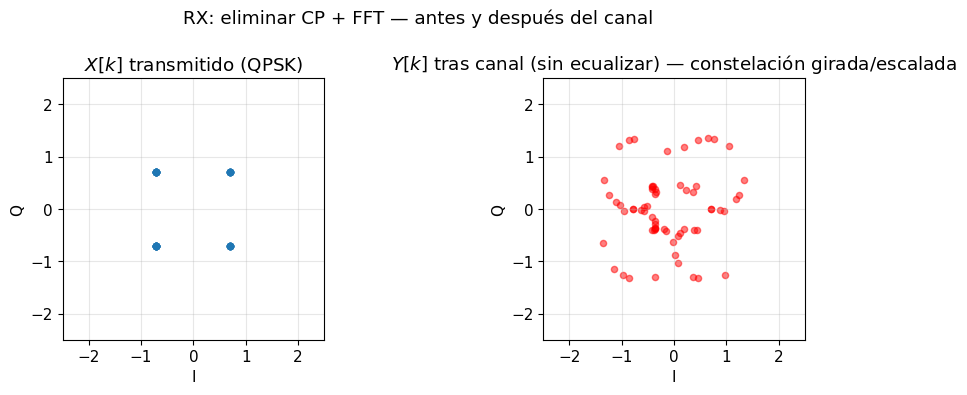

In [66]:
def ofdm_rx_no_channel(x_with_cp, N, N_CP):
    """Receptor OFDM básico: eliminar CP + FFT normalizada."""
    x = x_with_cp[N_CP:]
    return np.fft.fft(x, norm='ortho')

# Test 1: TX → (sin canal) → RX debe recuperar X exactamente
Y_ideal_b4 = ofdm_rx_no_channel(x_cp_b2, N, N_CP)
error_b4    = np.max(np.abs(Y_ideal_b4 - X_test_b2))
print(f'Sin canal  | Error máximo |Y[k] - X[k]|: {error_b4:.2e}  (debe ser ~0)')

# Test 2: aplicar RX sobre señal con canal → Y[k] = H[k]·X[k]
Y_ch_b4 = ofdm_rx_no_channel(y_ch_b3, N, N_CP)   # disponible en Bloque 5

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].scatter(X_test_b2.real, X_test_b2.imag, s=20, alpha=0.5)
axes[0].set_title('$X[k]$ transmitido (QPSK)')
axes[1].scatter(Y_ch_b4.real,   Y_ch_b4.imag,   s=20, alpha=0.5, color='red')
axes[1].set_title('$Y[k]$ tras canal (sin ecualizar) — constelación girada/escalada')
for ax in axes:
    ax.set_xlabel('I'); ax.set_ylabel('Q')
    ax.set_xlim(-2.5, 2.5); ax.set_ylim(-2.5, 2.5)
    ax.set_aspect('equal')
plt.suptitle('RX: eliminar CP + FFT — antes y después del canal')
plt.tight_layout(); plt.show()

### Bloque 5 — Ecualizador ZF (Zero Forcing)

**El problema:** el receptor tiene $Y[k] = H[k]\,X[k] + W[k]$. El canal $H[k]$ rotó y escaló cada símbolo de forma distinta — la constelación llegó distorsionada. El **ecualizador** deshace esa distorsión.

**Solución ZF:** si $H[k]$ es conocido, dividir por él recupera el símbolo:

$$\hat{X}^{ZF}[k] = \frac{Y[k]}{H[k]} = X[k] + \frac{W[k]}{H[k]}$$

**El costo:** el ruido también se divide por $H[k]$, amplificándose en subportadoras con canal débil. El SNR efectivo por subportadora es $\text{SNR}^{ZF}[k] = |H[k]|^2 \cdot \text{SNR}_0$.

---

### Cómo leer las figuras

**¿Qué significa el color de cada punto?**

El símbolo $X[k]$ va montado sobre la subportadora $k$. El canal le aplica una ganancia $|H[k]|$ que depende únicamente de la geometría del canal — no del símbolo. El **color de borde** de cada punto indica esa ganancia según el colormap *turbo*:

| Color | Ganancia $\|H[k]\|$ | Consecuencia |
|-------|-------------------|--------------|
| Azul oscuro / cian | Pequeña (subportadora muy atenuada) | El ruido se amplifica mucho al ecualizar |
| Verde / amarillo | Moderada | Ruido moderado tras ecualizador |
| Naranja / rojo | Grande (subportadora casi sin atenuar) | El ruido apenas se amplifica |

La asignación de un símbolo QPSK a una subportadora es arbitraria (los bits aleatorios van a parar a la subportadora k por el orden natural de la IFFT). Lo que importa es que el canal trata a cada subportadora de forma diferente.

**Figura 1 — cuatro paneles de izquierda a derecha:**

1. **$|H[k]|$ por subportadora** — muestra la ganancia real del canal en cada subportadora. Las que están bajas (azul/cian en los siguientes paneles) son las que el canal atenúa fuerte.

2. **$X[k]$ transmitido** — los 64 símbolos QPSK colocados exactamente en los 4 vértices de la constelación. Los colores ya aparecen porque cada punto pertenece a una subportadora concreta. En este panel todos los símbolos están en su sitio correcto.

3. **$Y[k]$ recibido sin ecualizar** — la constelación llega distorsionada. Los puntos azules/cian (subportadoras débiles) están muy dispersos: el canal los atenúa poco pero el ruido ocupa proporcionalmente más espacio. Los puntos rojos/naranjas están más agrupados.

4. **$\hat{X}^{ZF}[k]$ tras el ecualizador** — el ecualizador devuelve los símbolos cerca de los 4 vértices, pero los puntos **conservan su color original**. Los azules/cian siguen siendo los más dispersos: aunque el ecualizador corrigió la distorsión del canal, también amplificó el ruido $W[k]/H[k]$ — cuanto más débil era el canal, más ruido queda.

**Figura 2 — comparación QPSK (fila superior) vs 16-QAM (fila inferior):**

El mismo razonamiento aplica, pero ahora las regiones de decisión de 16-QAM son mucho más pequeñas. Un símbolo azul que en QPSK caía dentro de su cuadrante (y se decodificaba bien) puede cruzar fácilmente una frontera en 16-QAM y causar un error.


ZF sin ruido | Error máximo: 8.08e-16  (debe ser ~0)


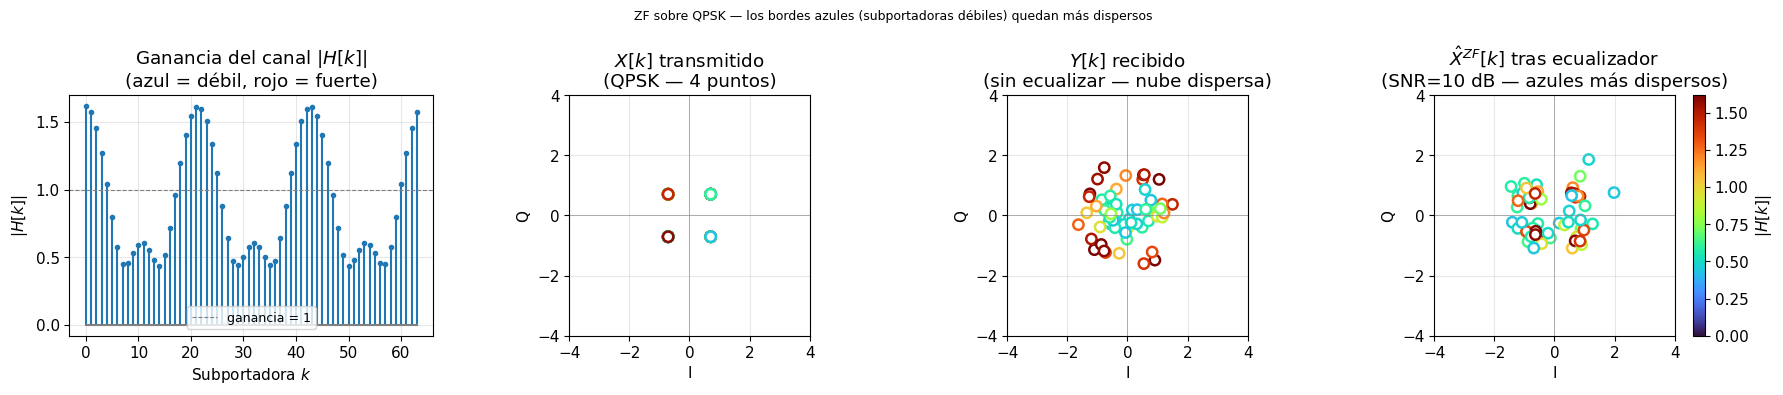

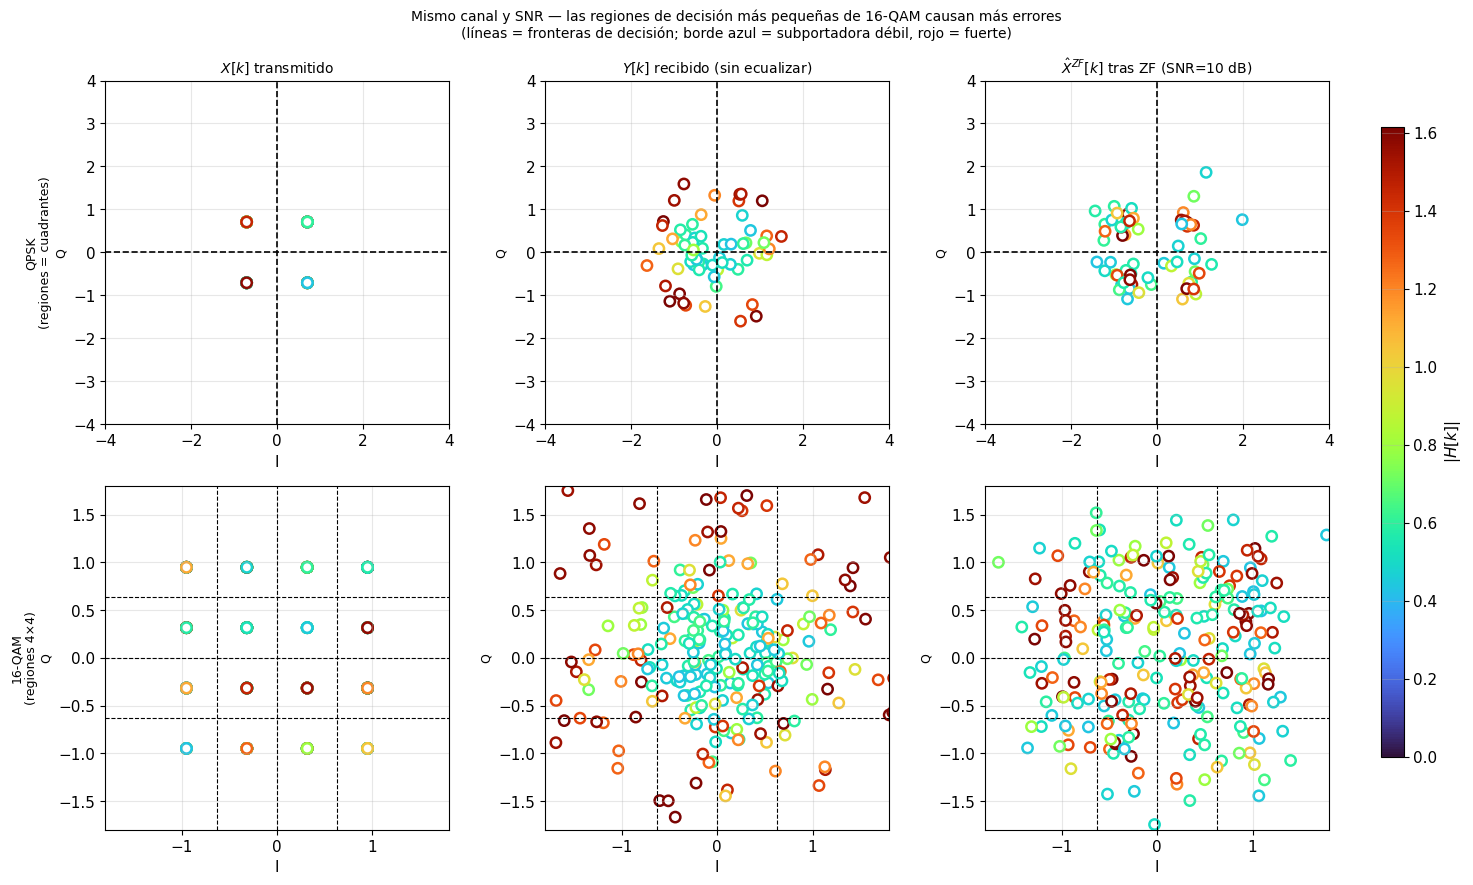

Canal: |H[k]| min=0.435 (k=14), max=1.616
SNR efectivo — subportadora más débil:  2.8 dB
SNR efectivo — subportadora más fuerte: 14.2 dB

Distancia mínima a frontera de decisión:
  QPSK:   0.707
  16-QAM: 0.316 (símbolo interior)


In [67]:
def zf_equalizer(Y, h, N):
    """ZF: divide por la DFT del canal → elimina distorsión (pero amplifica ruido)."""
    H = np.fft.fft(h, n=N)
    return Y / H

# ── Test 1: sin ruido — verificar recuperación perfecta ─────────────────────
X_zf_clean = zf_equalizer(Y_ch_b4, h_channel, N)
print(f'ZF sin ruido | Error máximo: {np.max(np.abs(X_zf_clean - X_test_b2)):.2e}  (debe ser ~0)')

# ── Test 2: con ruido — visualizar qué hace el ecualizador símbolo a símbolo ─
snr_b5   = 10   # dB
sigma_b5 = np.sqrt(10**(-snr_b5/10) / 2)
noise_b5 = sigma_b5 * (rng.normal(size=N+N_CP) + 1j*rng.normal(size=N+N_CP))
Y_noisy_b5 = ofdm_rx_no_channel(y_ch_b3 + noise_b5, N, N_CP)
X_zf_b5    = zf_equalizer(Y_noisy_b5, h_channel, N)   # disponible en Bloque 6

H_k_b5   = np.fft.fft(h_channel, n=N)
H_mag_b5 = np.abs(H_k_b5)

# turbo: azul oscuro (|H[k]|≈0, débil) → cian → verde → amarillo → naranja → rojo (fuerte)
# Espectro completo → colores muy distintos entre sí, siempre visibles sobre fondo blanco.
CMAP_B5 = 'turbo'
norm_b5 = plt.Normalize(vmin=0, vmax=H_mag_b5.max())

def scatter_zf(ax, data, colors, **kw):
    """Relleno blanco + borde coloreado por |H[k]| con colormap turbo."""
    ec = plt.cm.turbo(norm_b5(colors))
    return ax.scatter(data.real, data.imag, facecolors='white', edgecolors=ec,
                      linewidths=1.8, s=55, **kw)

# Figura 1: 4 paneles QPSK
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
axes[0].stem(np.arange(N), H_mag_b5, linefmt='C0-', markerfmt='C0.', basefmt='gray')
axes[0].axhline(1.0, color='gray', ls='--', lw=0.8, label='ganancia = 1')
axes[0].set_xlabel('Subportadora $k$'); axes[0].set_ylabel('$|H[k]|$')
axes[0].set_title('Ganancia del canal $|H[k]|$\n(azul = débil, rojo = fuerte)')
axes[0].legend(fontsize=9)
scatter_zf(axes[1], X_test_b2, H_mag_b5)
axes[1].set_title('$X[k]$ transmitido\n(QPSK — 4 puntos)')
scatter_zf(axes[2], Y_noisy_b5, H_mag_b5)
axes[2].set_title('$Y[k]$ recibido\n(sin ecualizar — nube dispersa)')
scatter_zf(axes[3], X_zf_b5, H_mag_b5)
axes[3].set_title(f'$\\hat{{X}}^{{ZF}}[k]$ tras ecualizador\n(SNR={snr_b5} dB — azules más dispersos)')
sm = plt.cm.ScalarMappable(cmap=CMAP_B5, norm=norm_b5); sm.set_array([])
plt.colorbar(sm, ax=axes[3], label='$|H[k]|$')
for ax in axes[1:]:
    ax.set_xlabel('I'); ax.set_ylabel('Q'); ax.set_xlim(-4, 4); ax.set_ylim(-4, 4)
    ax.set_aspect('equal'); ax.axhline(0, color='gray', lw=0.4); ax.axvline(0, color='gray', lw=0.4)
plt.suptitle('ZF sobre QPSK — los bordes azules (subportadoras débiles) quedan más dispersos', fontsize=9)
plt.tight_layout()
plt.savefig('figures/zf-equalizer-effect.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

# ── Figura 2: comparación QPSK vs 16-QAM ────────────────────────────────────
def qam16_map(bits):
    """16-QAM Gray coding: 4 bits → símbolo complejo con E[|s|²]=1."""
    b = bits.reshape(-1, 4)
    lut = np.array([-3, -1, 1, 3]) / np.sqrt(10)
    def gray_idx(g1, g0): return 2*g1 + (g1 ^ g0)
    return lut[gray_idx(b[:,0], b[:,1])] + 1j * lut[gray_idx(b[:,2], b[:,3])]

# 4 frames de 16-QAM para garantizar que los 16 puntos aparecen en el TX
n_frames_16 = 4
X16_l, Y16_l, Xzf16_l = [], [], []
for _ in range(n_frames_16):
    b16  = rng.integers(0, 2, N * 4)
    X16  = qam16_map(b16)
    y16  = apply_channel(ofdm_tx(X16, N_CP), h_channel)[:N + N_CP]
    n16  = sigma_b5 * (rng.normal(size=N+N_CP) + 1j*rng.normal(size=N+N_CP))
    Y16  = ofdm_rx_no_channel(y16 + n16, N, N_CP)
    X16_l.append(X16); Y16_l.append(Y16); Xzf16_l.append(zf_equalizer(Y16, h_channel, N))
X_16_all   = np.concatenate(X16_l)
Y_16_all   = np.concatenate(Y16_l)
Xzf_16_all = np.concatenate(Xzf16_l)
H_mag_16   = np.tile(H_mag_b5, n_frames_16)

def draw_decision_boundaries(ax, mod):
    if mod == 'qpsk':
        ax.axhline(0, color='k', lw=1.2, ls='--')
        ax.axvline(0, color='k', lw=1.2, ls='--')
    else:
        th = 2 / np.sqrt(10)
        for t in [-th, 0, th]:
            ax.axhline(t, color='k', lw=0.8, ls='--')
            ax.axvline(t, color='k', lw=0.8, ls='--')

fig2, axes2 = plt.subplots(2, 3, figsize=(15, 9))
titles_col = ['$X[k]$ transmitido', '$Y[k]$ recibido (sin ecualizar)',
              f'$\\hat{{X}}^{{ZF}}[k]$ tras ZF (SNR={snr_b5} dB)']
data_rows = [
    (X_test_b2, Y_noisy_b5,  X_zf_b5,    H_mag_b5, 'qpsk',  'QPSK\n(regiones = cuadrantes)', 4),
    (X_16_all,  Y_16_all,    Xzf_16_all, H_mag_16, '16qam', '16-QAM\n(regiones 4×4)',         1.8),
]
for row, (X_tx, Y_rx, X_zf, colors, mod, row_label, lim) in enumerate(data_rows):
    for col, (data, col_colors) in enumerate([(X_tx, colors), (Y_rx, colors), (X_zf, colors)]):
        ax = axes2[row, col]
        scatter_zf(ax, data, col_colors)
        draw_decision_boundaries(ax, mod)
        ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim); ax.set_aspect('equal')
        ax.set_xlabel('I')
        ax.set_ylabel(f'{row_label}\nQ' if col == 0 else 'Q', fontsize=9)
        if row == 0:
            ax.set_title(titles_col[col], fontsize=10)

sm2 = plt.cm.ScalarMappable(cmap=CMAP_B5, norm=norm_b5); sm2.set_array([])
plt.suptitle('Mismo canal y SNR — las regiones de decisión más pequeñas de 16-QAM causan más errores\n'
             '(líneas = fronteras de decisión; borde azul = subportadora débil, rojo = fuerte)', fontsize=10)
# Reserve 8% on the right for the colorbar so it sits outside the subplot grid
plt.tight_layout(rect=[0, 0, 0.92, 1])
cbar_ax2 = fig2.add_axes([0.93, 0.15, 0.015, 0.7])
fig2.colorbar(sm2, cax=cbar_ax2, label='$|H[k]|$')
plt.savefig('figures/zf-equalizer-qam-comparison.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

snr_lin_b5 = 10**(snr_b5/10)
print(f'Canal: |H[k]| min={H_mag_b5.min():.3f} (k={H_mag_b5.argmin()}), max={H_mag_b5.max():.3f}')
print(f'SNR efectivo — subportadora más débil:  {10*np.log10(H_mag_b5.min()**2 * snr_lin_b5):.1f} dB')
print(f'SNR efectivo — subportadora más fuerte: {10*np.log10(H_mag_b5.max()**2 * snr_lin_b5):.1f} dB')
print(f'\nDistancia mínima a frontera de decisión:')
print(f'  QPSK:   {1/np.sqrt(2):.3f}')
print(f'  16-QAM: {1/np.sqrt(10):.3f} (símbolo interior)')


### Bloque 6 — Ecualizador MMSE

**Entrada:** $Y[k]$, $H[k]$, SNR &nbsp;→&nbsp; **Operación:** inversión regularizada del canal &nbsp;→&nbsp; **Salida:** $\hat{X}^{MMSE}[k]$ con ruido acotado en *fades*

El MMSE añade un término $1/\text{SNR}$ en el denominador que actúa como regularizador — impide que la ganancia del ecualizador crezca sin límite cuando $H[k] \to 0$:

$$\hat{X}^{MMSE}[k] = \underbrace{\frac{1}{H[k]}}_{\text{ZF}} \cdot \underbrace{\frac{|H[k]|^2}{|H[k]|^2 + 1/\text{SNR}}}_{\alpha[k] \;\in\; (0,1)} \cdot Y[k] = \frac{H^*[k]}{|H[k]|^2 + 1/\text{SNR}}\,Y[k]$$

El factor $\alpha[k]$ es la clave: vale casi 1 cuando el canal es fuerte (MMSE ≈ ZF), y cae hacia 0 en *deep fade* (MMSE devuelve un estimado cercano a cero en lugar de ruido amplificado al infinito).

---

### Cómo leer la figura

La figura tiene tres paneles, con el mismo código de color turbo (azul = subportadora débil, rojo = fuerte):

1. **$\alpha[k]$ por subportadora** — muestra cuánto "frena" el MMSE en cada subportadora. Las barras azules/cian (canal débil) son bajas: el MMSE atenúa mucho esa subportadora, sacrificando algo de señal a cambio de no amplificar el ruido. Las barras rojas están cerca de 1: el MMSE se comporta casi igual que el ZF porque el canal es fuerte.

2. **ZF:** los puntos azules/cian están muy dispersos — el ZF los trató igual que los rojos e invirtió un canal pequeño, amplificando el ruido.

3. **MMSE:** los puntos azules/cian están más compactos que en ZF. El regularizador los anuló parcialmente (α pequeño) en lugar de amplificar el ruido. Los rojos son casi idénticos a los de ZF porque α ≈ 1.


α[k]:  min=0.654  max=0.963
α≈1 → MMSE ≈ ZF (canal fuerte)   |   α≪1 → MMSE atenúa (canal débil)


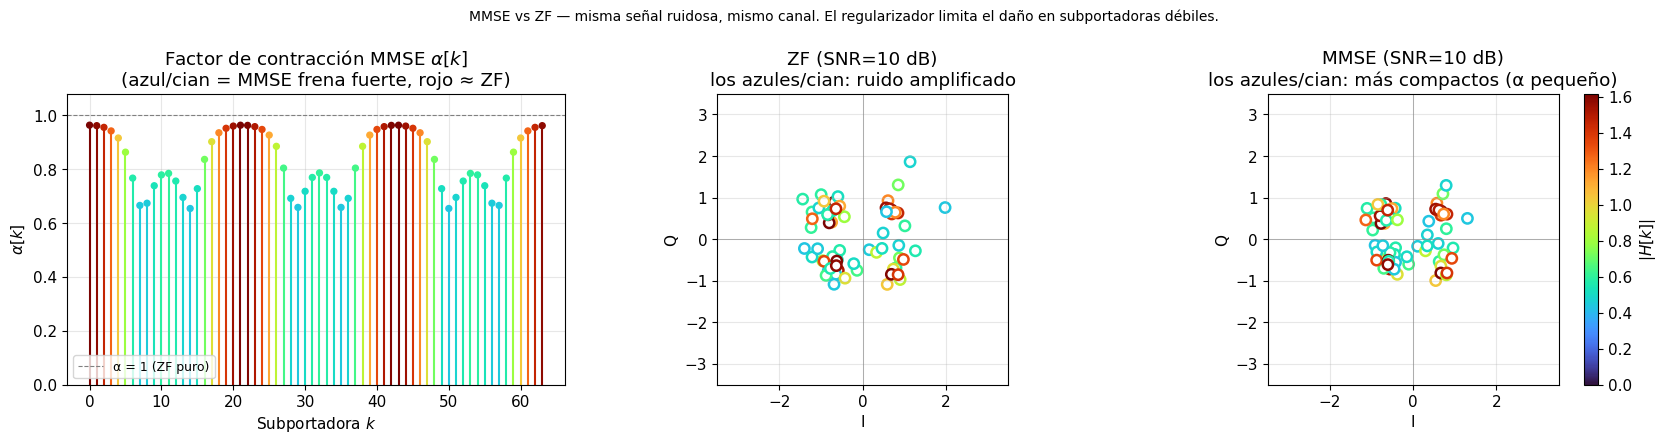

In [68]:
def mmse_equalizer(Y, h, N, SNR_dB):
    """MMSE: regulariza la inversión del canal → limita amplificación de ruido en fades."""
    H   = np.fft.fft(h, n=N)
    SNR = 10 ** (SNR_dB / 10)
    return (np.conj(H) / (np.abs(H)**2 + 1/SNR)) * Y

# Ecualizar con MMSE (reutiliza Y_noisy_b5 del Bloque 5)
X_mmse_b6 = mmse_equalizer(Y_noisy_b5, h_channel, N, snr_b5)

# Factor de contracción α[k] ∈ (0,1): indica cuánto "frena" el MMSE por subportadora
H_k_b6 = np.fft.fft(h_channel, n=N)
alpha   = np.abs(H_k_b6)**2 / (np.abs(H_k_b6)**2 + 1/10**(snr_b5/10))
print(f'α[k]:  min={alpha.min():.3f}  max={alpha.max():.3f}')
print('α≈1 → MMSE ≈ ZF (canal fuerte)   |   α≪1 → MMSE atenúa (canal débil)')

# ── Figura: α[k] + ZF + MMSE con colormap turbo ─────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))

# Panel 1: α[k] como barras verticales coloreadas por |H[k]|
bar_colors = plt.cm.turbo(norm_b5(H_mag_b5))
axes[0].vlines(np.arange(N), 0, alpha, colors=bar_colors, lw=1.5)
axes[0].scatter(np.arange(N), alpha, c=H_mag_b5, cmap='turbo',
                norm=norm_b5, s=18, zorder=5)
axes[0].axhline(1.0, color='gray', ls='--', lw=0.8, label='α = 1 (ZF puro)')
axes[0].set_ylim(0, 1.08)
axes[0].set_xlabel('Subportadora $k$')
axes[0].set_ylabel('$\\alpha[k]$')
axes[0].set_title('Factor de contracción MMSE $\\alpha[k]$\n(azul/cian = MMSE frena fuerte, rojo ≈ ZF)')
axes[0].legend(fontsize=9)

# Panel 2: ZF
scatter_zf(axes[1], X_zf_b5, H_mag_b5)
axes[1].set_title(f'ZF (SNR={snr_b5} dB)\nlos azules/cian: ruido amplificado')

# Panel 3: MMSE
scatter_zf(axes[2], X_mmse_b6, H_mag_b5)
axes[2].set_title(f'MMSE (SNR={snr_b5} dB)\nlos azules/cian: más compactos (α pequeño)')

for ax in axes[1:]:
    ax.set_xlabel('I'); ax.set_ylabel('Q')
    ax.set_xlim(-3.5, 3.5); ax.set_ylim(-3.5, 3.5)
    ax.set_aspect('equal')
    ax.axhline(0, color='gray', lw=0.4); ax.axvline(0, color='gray', lw=0.4)

sm = plt.cm.ScalarMappable(cmap='turbo', norm=norm_b5); sm.set_array([])
plt.colorbar(sm, ax=axes[2], label='$|H[k]|$')
plt.suptitle('MMSE vs ZF — misma señal ruidosa, mismo canal. '
             'El regularizador limita el daño en subportadoras débiles.', fontsize=10)
plt.tight_layout()
plt.savefig('figures/mmse-vs-zf-constellation.png', dpi=150,
            bbox_inches='tight', facecolor='white')
plt.show()


### Bloque 7 — Estimación de Canal con Pilotos (LS)

**Entrada:** $Y[k_p]$ en posiciones piloto + $X_p[k_p]$ conocido &nbsp;→&nbsp; **Operación:** $\hat{H}^{LS}[k_p] = Y[k_p]/X_p[k_p]$, luego interpolación lineal &nbsp;→&nbsp; **Salida:** $\hat{H}[k]$ para las $N$ subportadoras

En todos los ejercicios anteriores asumimos $H[k]$ perfectamente conocido. Este bloque muestra cómo estimarlo a partir de subportadoras piloto.

MSE estimación LS (sin ruido): 2.19e-01
Pilotos: 8/64 subportadoras (12% overhead)


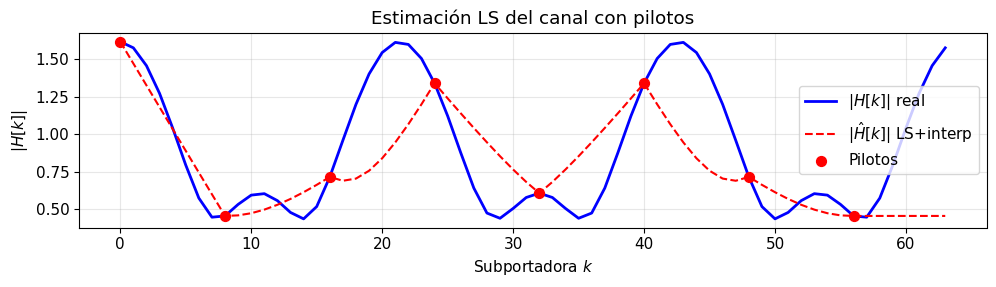

In [69]:
def ls_channel_estimate(Y, pilot_idx, X_pilot, N):
    """Estimación LS en pilotos + interpolación lineal a todas las subportadoras."""
    H_ls = Y[pilot_idx] / X_pilot
    H_est = (np.interp(np.arange(N), pilot_idx, H_ls.real) +
             1j * np.interp(np.arange(N), pilot_idx, H_ls.imag))
    return H_est

# Test: trama con pilotos cada 8 subportadoras (sin ruido)
pilot_sp_b7 = 8
p_idx_b7    = np.arange(0, N, pilot_sp_b7)
X_pilot_b7  = np.ones(len(p_idx_b7), dtype=complex)   # BPSK conocido = +1

X_frame_b7 = qpsk_map(rng.integers(0, 2, N * 2))
X_frame_b7[p_idx_b7] = X_pilot_b7
y_pilot_b7  = apply_channel(ofdm_tx(X_frame_b7, N_CP), h_channel)
Y_pilot_b7  = ofdm_rx_no_channel(y_pilot_b7, N, N_CP)
H_est_b7    = ls_channel_estimate(Y_pilot_b7, p_idx_b7, X_pilot_b7, N)
H_true_b7   = np.fft.fft(h_channel, n=N)
H_ls_pts_b7 = Y_pilot_b7[p_idx_b7] / X_pilot_b7

mse_b7 = np.mean(np.abs(H_est_b7 - H_true_b7)**2)
print(f'MSE estimación LS (sin ruido): {mse_b7:.2e}')
print(f'Pilotos: {len(p_idx_b7)}/{N} subportadoras ({100*len(p_idx_b7)/N:.0f}% overhead)')

fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(np.abs(H_true_b7), 'b-',  lw=2,   label='$|H[k]|$ real')
ax.plot(np.abs(H_est_b7),  'r--', lw=1.5, label='$|\\hat{H}[k]|$ LS+interp')
ax.scatter(p_idx_b7, np.abs(H_ls_pts_b7), s=50, color='red', zorder=5, label='Pilotos')
ax.set_xlabel('Subportadora $k$'); ax.set_ylabel('$|H[k]|$')
ax.set_title('Estimación LS del canal con pilotos')
ax.legend(); plt.tight_layout(); plt.show()

### Bloque 8 — QAM Demapper

**Entrada:** símbolo complejo ecualizado $\hat{X}[k]$ &nbsp;→&nbsp; **Operación:** asignar al punto de constelación más cercano &nbsp;→&nbsp; **Salida:** $\log_2 M$ bits por subportadora

El ecualizador entrega $\hat{X}[k]$: un número complejo en el plano I/Q. El demapper mira en qué cuadrante cae y lo asigna al punto QPSK más cercano. Para QPSK las regiones de decisión son los cuatro cuadrantes — la frontera es $\mathrm{Re}\{\hat{X}\} = 0$ e $\mathrm{Im}\{\hat{X}\} = 0$.

Con Gray coding los cuadrantes se etiquetan de modo que vecinos difieran en 1 bit: $(b_0, b_1) = (0,0)$ → $+I+Q$; $(1,0)$ → $-I+Q$; $(1,1)$ → $-I-Q$; $(0,1)$ → $+I-Q$.

**Cómo leer la figura.** El scatter muestra los símbolos ecualizados $\hat{X}[k]$ (ZF, SNR = 10 dB). El color indica $|H[k]|$: azul = subportadora débil, rojo = fuerte. Las líneas discontinuas son las fronteras de decisión. Los puntos que cruzan una frontera — sobre todo los azules — producen errores de bit.

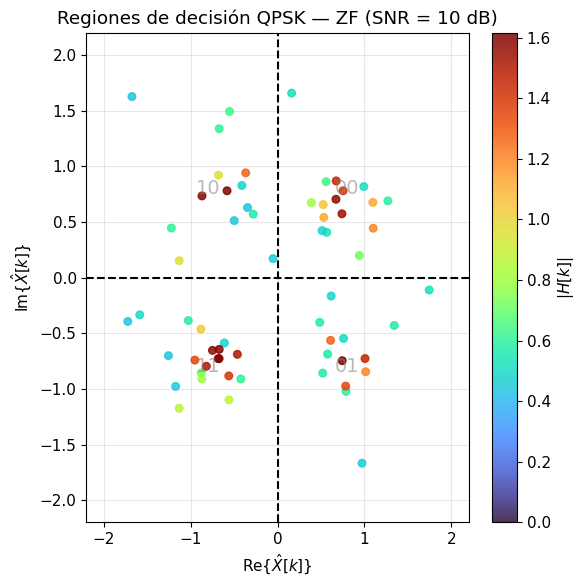

Errores: 1/128  |  BER frame: 0.008


In [70]:
def qpsk_demap(X_hat):
    """Hard decision QPSK con Gray coding: Re<0 → b0=1, Im<0 → b1=1."""
    bits = np.zeros(len(X_hat) * 2, dtype=int)
    bits[0::2] = (X_hat.real < 0).astype(int)
    bits[1::2] = (X_hat.imag < 0).astype(int)
    return bits

# Frame de prueba — mismas condiciones que Bloque 5 (snr_b5, h_channel)
bits_test_b8 = rng.integers(0, 2, N * 2)
X_test_b8    = qpsk_map(bits_test_b8)
x_cp_b8      = ofdm_tx(X_test_b8, N_CP)
y_b8         = apply_channel(x_cp_b8, h_channel)[:N + N_CP]
y_b8        += sigma_b5 * (rng.normal(size=N+N_CP) + 1j*rng.normal(size=N+N_CP))
Y_b8         = ofdm_rx_no_channel(y_b8, N, N_CP)
X_zf_b8      = zf_equalizer(Y_b8, h_channel, N)
bits_rx_b8   = qpsk_demap(X_zf_b8)
H_mag_b8     = np.abs(np.fft.fft(h_channel, n=N))

# ── Figura: regiones de decisión QPSK ────────────────────────────────────────
fig, ax = plt.subplots(figsize=(6, 6))
sc = ax.scatter(X_zf_b8.real, X_zf_b8.imag, c=H_mag_b8, cmap='turbo',
                norm=norm_b5, s=30, alpha=0.85, zorder=3)
ax.axhline(0, color='k', lw=1.5, ls='--')
ax.axvline(0, color='k', lw=1.5, ls='--')
for xp, yp, lbl in [(0.8, 0.8,'00'), (-0.8, 0.8,'10'), (-0.8,-0.8,'11'), (0.8,-0.8,'01')]:
    ax.text(xp, yp, lbl, ha='center', va='center', fontsize=14, color='gray', alpha=0.55)
plt.colorbar(sc, ax=ax, label='$|H[k]|$')
ax.set_xlim(-2.2, 2.2); ax.set_ylim(-2.2, 2.2)
ax.set_xlabel(r'$\mathrm{Re}\{\hat{X}[k]\}$')
ax.set_ylabel(r'$\mathrm{Im}\{\hat{X}[k]\}$')
ax.set_title(f'Regiones de decisión QPSK — ZF (SNR = {snr_b5} dB)')
plt.tight_layout()
plt.savefig('figures/qpsk-decision-regions.png', dpi=150, bbox_inches='tight')
plt.show()

n_err = np.sum(bits_test_b8 != bits_rx_b8)
print(f'Errores: {n_err}/{len(bits_test_b8)}  |  BER frame: {n_err/len(bits_test_b8):.3f}')

### Bloque 9 — Cadena Completa: BER de Extremo a Extremo

**Entrada:** bits aleatorios + $E_b/N_0$ &nbsp;→&nbsp; **Operación:** cadena completa TX → canal → ruido → RX → ecualización → demapper &nbsp;→&nbsp; **Salida:** BER simulada

Este bloque integra los ocho anteriores en un único flujo de datos y produce la curva BER que caracteriza el sistema OFDM completo.

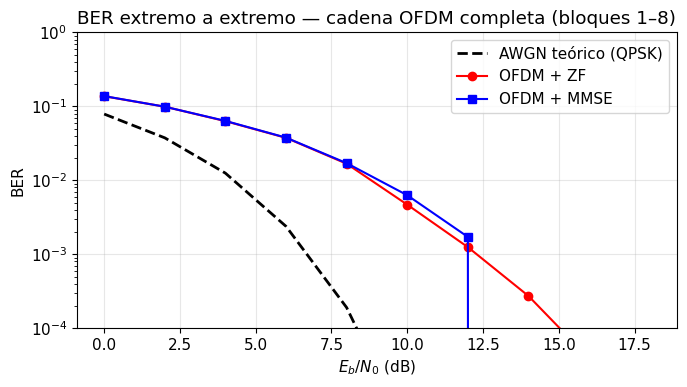

Sección 1 completada. Todos los bloques operativos y listos para los ejercicios.


In [71]:
def ofdm_ber_quick(EbN0_dB_val, N, N_CP, h, n_frames=200, equalize='zf'):
    """Simulación rápida de BER OFDM (QPSK, canal perfecto conocido)."""
    k_bits  = 2
    SNR_lin = 10 ** (EbN0_dB_val / 10)
    SNR_dB  = EbN0_dB_val + 10 * np.log10(k_bits)   # SNR = Eb/N0 · k_bits
    sigma   = np.sqrt(1 / (k_bits * SNR_lin * 2))
    errors, total = 0, 0
    for _ in range(n_frames):
        bits   = rng.integers(0, 2, N * k_bits)
        X      = qpsk_map(bits)
        x_cp_  = ofdm_tx(X, N_CP)
        y_     = apply_channel(x_cp_, h)[:N + N_CP]
        y_    += sigma * (rng.normal(size=N+N_CP) + 1j*rng.normal(size=N+N_CP))
        Y_     = ofdm_rx_no_channel(y_, N, N_CP)
        X_hat  = (zf_equalizer(Y_, h, N) if equalize == 'zf'
                  else mmse_equalizer(Y_, h, N, SNR_dB))
        errors += np.sum(bits != qpsk_demap(X_hat))
        total  += N * k_bits
    return errors / total

EbN0_range_b9 = np.arange(0, 20, 2)
ber_zf_b9     = [ofdm_ber_quick(e, N, N_CP, h_channel, equalize='zf')   for e in EbN0_range_b9]
ber_mmse_b9   = [ofdm_ber_quick(e, N, N_CP, h_channel, equalize='mmse') for e in EbN0_range_b9]
ber_awgn_b9   = 0.5 * erfc(np.sqrt(10**(EbN0_range_b9/10)))

fig, ax = plt.subplots(figsize=(7, 4))
ax.semilogy(EbN0_range_b9, ber_awgn_b9, 'k--', lw=2,   label='AWGN teórico (QPSK)')
ax.semilogy(EbN0_range_b9, ber_zf_b9,   'r-o', lw=1.5, markersize=6, label='OFDM + ZF')
ax.semilogy(EbN0_range_b9, ber_mmse_b9, 'b-s', lw=1.5, markersize=6, label='OFDM + MMSE')
ax.set_xlabel('$E_b/N_0$ (dB)'); ax.set_ylabel('BER')
ax.set_title('BER extremo a extremo — cadena OFDM completa (bloques 1–8)')
ax.legend(); ax.set_ylim(1e-4, 1)
plt.tight_layout()
plt.savefig('figures/ofdm-ber-equalizers.png', dpi=150, bbox_inches='tight')
plt.show()
print('Sección 1 completada. Todos los bloques operativos y listos para los ejercicios.')

---
## Sección 2 — Ejercicios de Integración

Todos los bloques del transceptor están definidos y probados en la Sección 1. Los ejercicios siguientes los combinan para explorar el sistema OFDM en su conjunto: efectos del canal, comparación de ecualizadores y análisis de BER.

---
## Ejercicio 1 — Señal OFDM en Tiempo y Frecuencia
### ⏱ Tiempo estimado: 15 min

Genera un símbolo OFDM y visualiza su estructura en los dominios temporal y frecuencial.

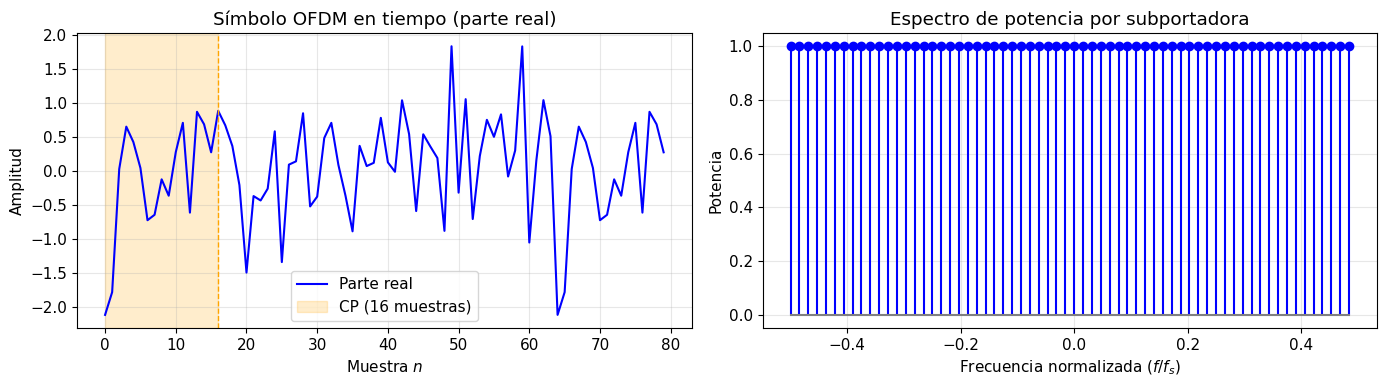

Longitud total del símbolo transmitido: 80 muestras = N + N_CP = 64 + 16
Potencia media de la señal OFDM: 1.0143 (teórica = 1.0)


In [72]:
def qpsk_map(bits):
    """Mapeado QPSK Gray: 2 bits → 1 símbolo complejo (|s|² = 1)."""
    # 00→(+1+j), 01→(+1-j), 10→(-1+j), 11→(-1-j)
    b0, b1 = bits[0::2], bits[1::2]
    I = 1 - 2*b0          # 0→+1, 1→-1
    Q = 1 - 2*b1
    return (I + 1j*Q) / np.sqrt(2)  # energía media = 1


def ofdm_tx(X, N_CP):
    """Genera símbolo OFDM: IFFT + añadir CP."""
    x = np.fft.ifft(X, norm='ortho')       # IFFT normalizada: E[|x|²] = E[|X|²]
    cp = x[-N_CP:]                          # últimas N_CP muestras
    return np.concatenate([cp, x])          # [CP | símbolo]


# Genera un símbolo OFDM con N subportadoras QPSK aleatorias
bits_tx = rng.integers(0, 2, N * k)
X_tx = qpsk_map(bits_tx)                   # N símbolos QPSK
x_ofdm = ofdm_tx(X_tx, N_CP)              # símbolo OFDM con CP

# Visualización
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Panel izquierdo: dominio temporal
t = np.arange(len(x_ofdm))
axes[0].plot(t, x_ofdm.real, 'b-', lw=1.5, label='Parte real')
axes[0].axvspan(0, N_CP, alpha=0.2, color='orange', label=f'CP ({N_CP} muestras)')
axes[0].axvline(N_CP, color='orange', ls='--', lw=1)
axes[0].set_xlabel('Muestra $n$')
axes[0].set_ylabel('Amplitud')
axes[0].set_title('Símbolo OFDM en tiempo (parte real)')
axes[0].legend()

# Panel derecho: espectro de potencia
X_spectrum = np.fft.fft(x_ofdm[N_CP:], norm='ortho')  # FFT del símbolo sin CP
freqs = np.fft.fftfreq(N)
psd = np.abs(X_spectrum)**2
axes[1].stem(np.fft.fftshift(freqs), np.fft.fftshift(psd),
             linefmt='b-', markerfmt='bo', basefmt='gray')
axes[1].set_xlabel('Frecuencia normalizada ($f/f_s$)')
axes[1].set_ylabel('Potencia')
axes[1].set_title('Espectro de potencia por subportadora')

plt.tight_layout()
plt.savefig('figures/ofdm-time-domain.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

print(f'Longitud total del símbolo transmitido: {len(x_ofdm)} muestras = N + N_CP = {N} + {N_CP}')
print(f'Potencia media de la señal OFDM: {np.mean(np.abs(x_ofdm)**2):.4f} (teórica = 1.0)')

### Preguntas de reflexión — Ejercicio 1

1. ¿Qué relación ves entre la región naranja (CP) y el final del símbolo OFDM? ¿Son idénticas?

2. El espectro de potencia muestra N picos. ¿Esperarías que todos tengan la misma potencia? ¿Por qué en la práctica varían?
   > *Pista: los símbolos QPSK tienen amplitud constante |s|=1, pero la DFT de una secuencia aleatoria no tiene potencia uniforme.*

3. Modifica el código para generar un símbolo con solo las 8 subportadoras centrales activas (el resto a cero). ¿Cómo cambia la señal en el dominio temporal?

---
## Ejercicio 2 — ISI sin CP vs con CP
### ⏱ Tiempo estimado: 20 min

Observa el efecto del canal multipath sobre la constelación recibida, con y sin CP.

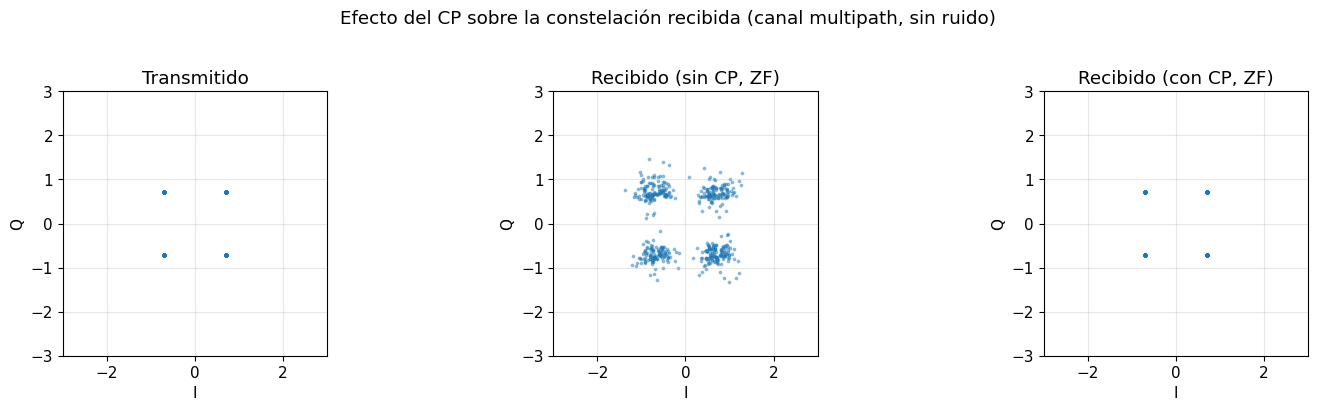

SER con CP (sin ruido): 0.000000 (esperado: 0)
Con CP y canal conocido, la recuperación es perfecta en ausencia de ruido.


In [73]:
def apply_channel(x_signal, h):
    """Convolución lineal: simula el canal multipath."""
    return np.convolve(x_signal, h, mode='full')[:len(x_signal)]


def ofdm_rx_with_channel(y_received, N, N_CP, h, equalize='zf', SNR_dB=30):
    """
    Receptor OFDM completo:
    1. Elimina CP
    2. FFT
    3. Ecualización ZF o MMSE usando H[k] perfecto (canal conocido)
    """
    x = y_received[N_CP:]               # eliminar CP
    Y = np.fft.fft(x, norm='ortho')    # FFT

    # DFT del canal (N puntos)
    H = np.fft.fft(h, n=N)             # H[k]

    if equalize == 'zf':
        X_hat = Y / H
    elif equalize == 'mmse':
        SNR_lin = 10 ** (SNR_dB / 10)
        X_hat = (np.conj(H) / (np.abs(H)**2 + 1/SNR_lin)) * Y
    else:
        X_hat = Y  # sin ecualización

    return X_hat


# Transmitir N_sym símbolos OFDM consecutivos
N_sym = 100
all_bits = rng.integers(0, 2, N_sym * N * k)

# --- CASO A: sin CP ---
X_hat_nocp_list = []
X_tx_list = []
prev_tail = np.zeros(L - 1, dtype=complex)  # cola del símbolo anterior

for s in range(N_sym):
    bits_s = all_bits[s * N * k:(s+1) * N * k]
    X_s = qpsk_map(bits_s)
    X_tx_list.append(X_s)
    # Sin CP: transmitir solo el símbolo OFDM
    x_s = np.fft.ifft(X_s, norm='ortho')
    # Canal: añadir ISI de la cola del símbolo anterior
    x_with_tail = np.concatenate([prev_tail, x_s])
    y_s = apply_channel(x_with_tail, h_channel)[L-1:]  # tomar las N muestras útiles
    prev_tail = x_s[-(L-1):]
    Y_s = np.fft.fft(y_s, norm='ortho')
    # Sin ecualización para ver el efecto del canal
    H_k = np.fft.fft(h_channel, n=N)
    X_hat_nocp_list.append(Y_s / H_k)

# --- CASO B: con CP ---
X_hat_cp_list = []
for s in range(N_sym):
    bits_s = all_bits[s * N * k:(s+1) * N * k]
    X_s = qpsk_map(bits_s)
    x_s_cp = ofdm_tx(X_s, N_CP)
    y_s_cp = apply_channel(x_s_cp, h_channel)
    y_s_cp = y_s_cp[:N + N_CP]  # longitud correcta
    X_hat_s = ofdm_rx_with_channel(y_s_cp, N, N_CP, h_channel, equalize='zf')
    X_hat_cp_list.append(X_hat_s)

X_tx_all   = np.concatenate(X_tx_list)
X_nocp_all = np.concatenate(X_hat_nocp_list)
X_cp_all   = np.concatenate(X_hat_cp_list)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, data, title in zip(axes,
    [X_tx_all[:500], X_nocp_all[:500], X_cp_all[:500]],
    ['Transmitido', 'Recibido (sin CP, ZF)', 'Recibido (con CP, ZF)']):
    ax.scatter(data.real, data.imag, s=3, alpha=0.4)
    ax.set_title(title)
    ax.set_xlabel('I'); ax.set_ylabel('Q')
    ax.set_xlim(-3, 3); ax.set_ylim(-3, 3)
    ax.set_aspect('equal')

plt.suptitle('Efecto del CP sobre la constelación recibida (canal multipath, sin ruido)', y=1.02)
plt.tight_layout()
plt.savefig('figures/cp-effect-constellation.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

# Calcular SER
def qpsk_decide(X):
    return np.sign(X.real).astype(int), np.sign(X.imag).astype(int)

I_tx, Q_tx = qpsk_decide(X_tx_all)
_, _ = qpsk_decide(X_nocp_all)
I_cp, Q_cp = qpsk_decide(X_cp_all)

ser_cp = np.mean((qpsk_decide(X_cp_all)[0] != I_tx) | (qpsk_decide(X_cp_all)[1] != Q_tx))
print(f'SER con CP (sin ruido): {ser_cp:.6f} (esperado: 0)')
print('Con CP y canal conocido, la recuperación es perfecta en ausencia de ruido.')

### Preguntas de reflexión — Ejercicio 2

1. En la constelación sin CP, ¿ves puntos aislados en las 4 esquinas o una nube dispersa? ¿Por qué la interferencia multipath produce este patrón?

2. Con CP, la constelación recuperada debería ser perfecta (SER=0 sin ruido). ¿Se cumple? ¿Qué ocurriría si el canal tuviera un camino con retardo mayor que N_CP?

3. Modifica el canal para que tenga un camino en el índice `l = N_CP + 2` (mayor que N_CP). ¿Qué le ocurre a la constelación recuperada?

---
## Ejercicio 3 — Cadena IFFT/FFT sin Canal
### ⏱ Tiempo estimado: 10 min

Verifica que la cadena TX → (sin canal) → RX recupera los símbolos exactamente.

Error máximo |X_rx - X_tx|: 3.33e-16
Recuperación perfecta: True


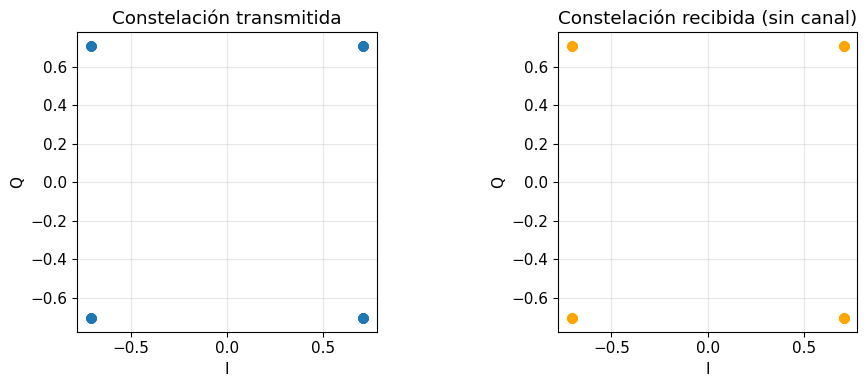

Las constelaciones son idénticas: la cadena IFFT → (sin canal) → FFT es invertible perfectamente.


In [74]:
def ofdm_rx_no_channel(x_with_cp, N, N_CP):
    """Receptor OFDM: eliminar CP + FFT."""
    x = x_with_cp[N_CP:]                    # eliminar CP
    Y = np.fft.fft(x, norm='ortho')         # FFT
    return Y


# Sin canal: conectar TX directamente a RX
X_rx_ideal = ofdm_rx_no_channel(x_ofdm, N, N_CP)

# Comparar símbolos transmitidos y recibidos
error = np.max(np.abs(X_rx_ideal - X_tx))
print(f'Error máximo |X_rx - X_tx|: {error:.2e}')
print(f'Recuperación perfecta: {error < 1e-10}')

# Visualizar constelación
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].scatter(X_tx.real, X_tx.imag, s=40, alpha=0.7, label='Transmitido $X_k$')
axes[0].set_title('Constelación transmitida')
axes[0].set_xlabel('I'); axes[0].set_ylabel('Q')
axes[0].set_aspect('equal')

axes[1].scatter(X_rx_ideal.real, X_rx_ideal.imag, s=40, alpha=0.7, color='orange', label='Recibido $Y_k$ (sin canal)')
axes[1].set_title('Constelación recibida (sin canal)')
axes[1].set_xlabel('I'); axes[1].set_ylabel('Q')
axes[1].set_aspect('equal')

plt.tight_layout()
plt.show()
print('Las constelaciones son idénticas: la cadena IFFT → (sin canal) → FFT es invertible perfectamente.')

---
## Ejercicio 4 — Ecualización ZF vs MMSE
### ⏱ Tiempo estimado: 20 min

Compara los ecualizadores ZF y MMSE en un canal con ganancia nula en algunas subportadoras.

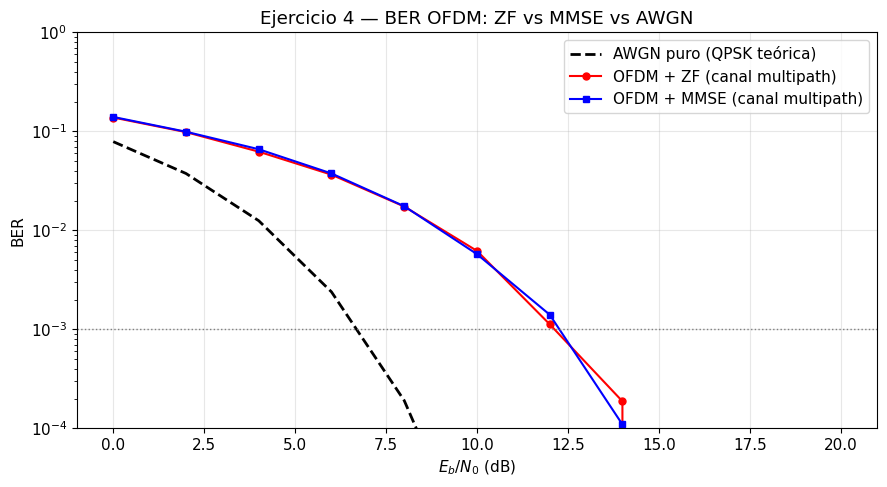

Ganancia mínima del canal: 0.435 (subportadora 14)
Ganancia máxima del canal: 1.616 (subportadora 0)


In [75]:
def simulate_ofdm_ber(EbN0_dB_range, N, N_CP, h, M=4, N_frames=500, equalize='zf'):
    """
    Simula BER de OFDM sobre canal multipath con ecualización ZF o MMSE.
    Canal perfecto conocido en el receptor.
    """
    k = int(np.log2(M))
    ber = np.zeros(len(EbN0_dB_range))

    for i, EbN0_dB in enumerate(EbN0_dB_range):
        SNR_lin = 10 ** (EbN0_dB / 10)
        # Potencia de ruido por muestra: sigma² = E_s/(k * SNR) = 1/(k*SNR)
        sigma2 = 1 / (k * SNR_lin)
        # SNR en banda (por subportadora): Eb/N0 × k_bits
        SNR_dB_actual = EbN0_dB + 10 * np.log10(k)

        errors = 0
        total  = 0

        for _ in range(N_frames):
            # TX
            bits = rng.integers(0, 2, N * k)
            X = qpsk_map(bits)  # QPSK
            x_cp = ofdm_tx(X, N_CP)

            # Canal + ruido
            y_ch = apply_channel(x_cp, h)
            y_ch = y_ch[:N + N_CP]
            noise = (rng.normal(0, np.sqrt(sigma2/2), N + N_CP) +
                     1j * rng.normal(0, np.sqrt(sigma2/2), N + N_CP))
            y_noisy = y_ch + noise

            # RX
            X_hat = ofdm_rx_with_channel(y_noisy, N, N_CP, h,
                                         equalize=equalize, SNR_dB=SNR_dB_actual)

            # Detección QPSK
            bits_hat = qpsk_demap(X_hat)

            errors += np.sum(bits != bits_hat)
            total  += N * k

        ber[i] = errors / total

    return ber


def Q_func(x):
    return 0.5 * erfc(x / np.sqrt(2))


EbN0_dB = np.arange(0, 22, 2)
ber_zf   = simulate_ofdm_ber(EbN0_dB, N, N_CP, h_channel, equalize='zf')
ber_mmse = simulate_ofdm_ber(EbN0_dB, N, N_CP, h_channel, equalize='mmse')
ber_awgn = Q_func(np.sqrt(2 * 10**(EbN0_dB/10)))  # referencia AWGN + QPSK

fig, ax = plt.subplots(figsize=(9, 5))
ax.semilogy(EbN0_dB, ber_awgn, 'k--', lw=2, label='AWGN puro (QPSK teórica)')
ax.semilogy(EbN0_dB, ber_zf,   'r-o', lw=1.5, markersize=5, label='OFDM + ZF (canal multipath)')
ax.semilogy(EbN0_dB, ber_mmse, 'b-s', lw=1.5, markersize=5, label='OFDM + MMSE (canal multipath)')
ax.axhline(1e-3, color='gray', ls=':', lw=1)
ax.set_xlabel('$E_b/N_0$ (dB)')
ax.set_ylabel('BER')
ax.set_title('Ejercicio 4 — BER OFDM: ZF vs MMSE vs AWGN')
ax.legend()
ax.set_ylim(1e-4, 1)
plt.tight_layout()
plt.savefig('figures/ofdm-ber-equalizers.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

# Analizar ganancias del canal por subportadora
H_k = np.fft.fft(h_channel, n=N)
print(f'Ganancia mínima del canal: {np.min(np.abs(H_k)):.3f} (subportadora {np.argmin(np.abs(H_k))})')
print(f'Ganancia máxima del canal: {np.max(np.abs(H_k)):.3f} (subportadora {np.argmax(np.abs(H_k))})')

### Preguntas de reflexión — Ejercicio 4

1. ¿Qué ecualizador da menor BER a SNR alta? ¿Y a SNR baja? ¿Por qué?
   > *Pista: a SNR baja, el ZF amplifica el ruido en subportadoras con canal débil; el MMSE lo limita.*

2. La BER sobre canal multipath es mayor que sobre AWGN puro (para el mismo Eb/N0). ¿Por qué?
   > *Pista: las subportadoras con ganancia baja contribuyen desproporcionadamente a la BER total.*

3. Modifica el canal para que sea completamente plano: `h_channel = np.array([1.0])`. ¿Esperarías que la BER con ZF coincida con la de AWGN? ¿Por qué?

---
## Ejercicio 5 — Estimación de Canal con Pilotos
### ⏱ Tiempo estimado: 20 min

En los ejercicios anteriores asumimos $H[k]$ perfectamente conocido. En la práctica el receptor debe **estimarlo** a partir de subportadoras piloto — posiciones donde el transmisor envía un símbolo conocido.

El estimador de mínimos cuadrados (LS) calcula la ganancia en cada piloto y luego interpola al resto:

$$\hat{H}^{LS}[k_p] = \frac{Y[k_p]}{X_p[k_p]} \tag{9}$$

La densidad mínima de pilotos está dictada por la coherence bandwidth: $\Delta k_p \cdot \Delta f \ll B_c$.

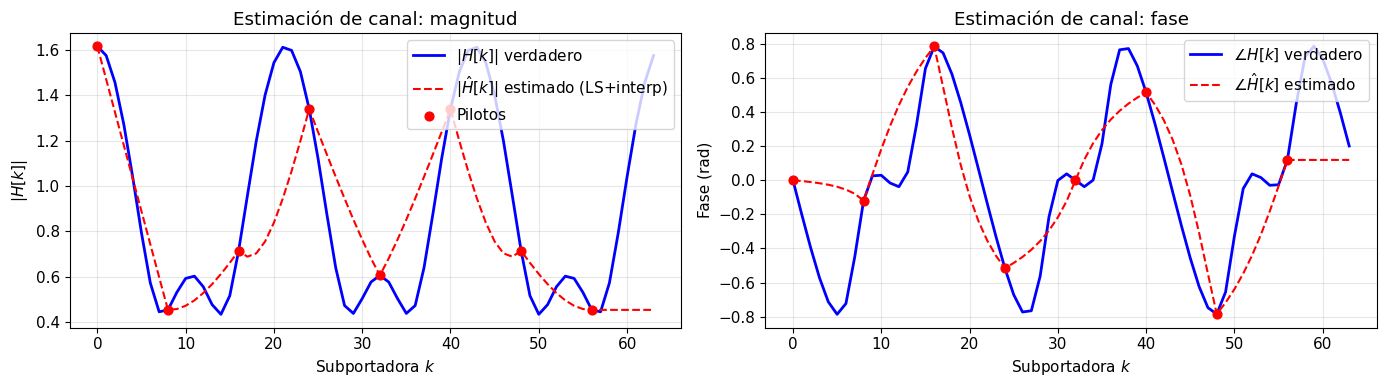

MSE estimación de canal (sin ruido): 2.19e-01
Pilotos: 8 de 64 subportadoras (12.5% overhead)


In [76]:
# --- Parámetros de pilotos ---
pilot_spacing = 8                                    # un piloto cada 8 subportadoras
pilot_idx     = np.arange(0, N, pilot_spacing)       # índices de subportadoras piloto
X_pilot       = np.ones(len(pilot_idx), dtype=complex)  # pilotos BPSK: valor conocido = +1

# --- TX: trama con pilotos en posiciones reservadas ---
X_frame = rng.choice([-1+0j, 1+0j, -1j, 1j], size=N) / np.sqrt(2)  # datos QPSK
X_frame[pilot_idx] = X_pilot                          # sobreescribir con pilotos conocidos
x_cp_pilot = ofdm_tx(X_frame, N_CP)

# --- Canal (sin ruido para ver la estimación limpia) ---
y_pilot = apply_channel(x_cp_pilot, h_channel)

# --- RX: eliminar CP + FFT ---
Y_pilot = np.fft.fft(y_pilot[N_CP:], norm='ortho')

# --- Estimación LS en posiciones piloto ---
H_ls_pilots = Y_pilot[pilot_idx] / X_pilot           # ĤLS[kp] = Y[kp] / Xp[kp]

# --- Interpolación lineal al resto de subportadoras ---
H_est = np.interp(np.arange(N),
                  pilot_idx,
                  H_ls_pilots.real) + \
        1j * np.interp(np.arange(N),
                       pilot_idx,
                       H_ls_pilots.imag)

# --- Canal verdadero (referencia) ---
H_true = np.fft.fft(h_channel, n=N)

# --- Visualización ---
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(np.abs(H_true),  'b-',  lw=2,   label='$|H[k]|$ verdadero')
axes[0].plot(np.abs(H_est),   'r--', lw=1.5, label='$|\\hat{H}[k]|$ estimado (LS+interp)')
axes[0].scatter(pilot_idx, np.abs(H_ls_pilots), s=40, color='red', zorder=5, label='Pilotos')
axes[0].set_xlabel('Subportadora $k$')
axes[0].set_ylabel('$|H[k]|$')
axes[0].set_title('Estimación de canal: magnitud')
axes[0].legend()

axes[1].plot(np.angle(H_true), 'b-',  lw=2,   label='$\\angle H[k]$ verdadero')
axes[1].plot(np.angle(H_est),  'r--', lw=1.5, label='$\\angle \\hat{H}[k]$ estimado')
axes[1].scatter(pilot_idx, np.angle(H_ls_pilots), s=40, color='red', zorder=5)
axes[1].set_xlabel('Subportadora $k$')
axes[1].set_ylabel('Fase (rad)')
axes[1].set_title('Estimación de canal: fase')
axes[1].legend()

plt.tight_layout()
plt.savefig('figures/channel-estimation-pilots.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

mse = np.mean(np.abs(H_est - H_true)**2)
print(f'MSE estimación de canal (sin ruido): {mse:.2e}')
print(f'Pilotos: {len(pilot_idx)} de {N} subportadoras ({100*len(pilot_idx)/N:.1f}% overhead)')

### Preguntas de reflexión — Ejercicio 5

1. ¿El estimador LS reproduce fielmente $|H[k]|$ y $\angle H[k]$ entre los pilotos? ¿Dónde es mayor el error de interpolación?

2. Reduce el espaciado de pilotos a `pilot_spacing = 4` y luego auméntalo a `pilot_spacing = 16`. ¿Cómo cambia el MSE? ¿Existe un espaciado mínimo que sigue dando buena estimación?
   > *Pista: compara el espaciado con $B_c / \Delta f$ para el canal de referencia.*

3. Añade ruido (`SNR_dB = 15`) antes de la estimación y observa cómo afecta el MSE. ¿Cuál es el trade-off entre densidad de pilotos y SNR?

---
## Ejercicio 6 — BER de OFDM vs AWGN y Análisis del Canal
### ⏱ Tiempo estimado: 25 min

Analiza la respuesta en frecuencia del canal y su impacto en la BER por subportadora.

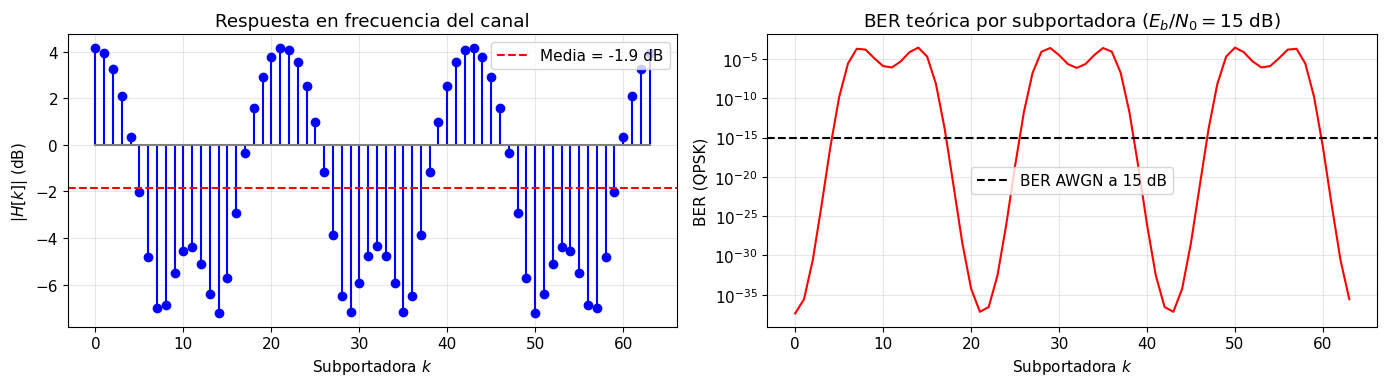

BER global OFDM sobre canal multipath a 15 dB: 3.42e-05
BER AWGN de referencia a 15 dB:                 9.12e-16
Degradación debida al canal: 105.7 dB equivalentes
Figuras para apuntes guardadas.


In [77]:
# Respuesta en frecuencia del canal
H_k = np.fft.fft(h_channel, n=N)
H_mag_dB = 20 * np.log10(np.abs(H_k) + 1e-10)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Panel izquierdo: respuesta en frecuencia del canal
axes[0].stem(np.arange(N), H_mag_dB, linefmt='b-', markerfmt='bo', basefmt='gray')
axes[0].axhline(np.mean(H_mag_dB), color='r', ls='--', label=f'Media = {np.mean(H_mag_dB):.1f} dB')
axes[0].set_xlabel('Subportadora $k$')
axes[0].set_ylabel('$|H[k]|$ (dB)')
axes[0].set_title('Respuesta en frecuencia del canal')
axes[0].legend()

# Panel derecho: BER por subportadora a SNR = 15 dB
SNR_target = 15  # dB
snr_per_subcarrier_dB = H_mag_dB + SNR_target  # ganancia por subportadora
ber_per_sc = Q_func(np.sqrt(2 * 10**(snr_per_subcarrier_dB/10)))

axes[1].semilogy(np.arange(N), ber_per_sc, 'r-', lw=1.5)
axes[1].axhline(Q_func(np.sqrt(2 * 10**(SNR_target/10))), color='k', ls='--',
                label=f'BER AWGN a {SNR_target} dB')
axes[1].set_xlabel('Subportadora $k$')
axes[1].set_ylabel('BER (QPSK)')
axes[1].set_title(f'BER teórica por subportadora ($E_b/N_0 = {SNR_target}$ dB)')
axes[1].legend()

plt.tight_layout()
plt.savefig('figures/ofdm-per-subcarrier-ber.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

# BER global vs AWGN a SNR = 15 dB
ber_global = np.mean(ber_per_sc)
ber_awgn_ref = Q_func(np.sqrt(2 * 10**(SNR_target/10)))
print(f'BER global OFDM sobre canal multipath a {SNR_target} dB: {ber_global:.2e}')
print(f'BER AWGN de referencia a {SNR_target} dB:                 {ber_awgn_ref:.2e}')
print(f'Degradación debida al canal: {10*np.log10(ber_global/ber_awgn_ref):.1f} dB equivalentes')

# Guardar figura de subportadoras OFDM
f = np.linspace(-3, 3, 2000)
colors = plt.cm.tab10(np.linspace(0, 1, 6))
fig2, ax2 = plt.subplots(figsize=(7, 4))
for idx, sc in enumerate([-2, -1, 0, 1, 2, 3]):
    sinc_env = np.sinc(f - sc)
    ax2.plot(f, np.abs(sinc_env), color=colors[idx], lw=1.5)
ax2.set_xlabel('Frecuencia normalizada ($\\times \\Delta f$)')
ax2.set_ylabel('Amplitud')
ax2.set_title('Subportadoras OFDM: ortogonalidad espectral')
ax2.set_xlim(-3, 3)
plt.tight_layout()
plt.savefig('figures/ofdm-subcarriers.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.close('all')

# Guardar figura CP — stem plot (x[n] es una secuencia discreta, no una onda continua)
x_demo   = np.fft.ifft(qpsk_map(rng.integers(0, 2, N*k)), norm='ortho').real
x_with_cp = np.concatenate([x_demo[-N_CP:], x_demo])
t_full   = np.arange(len(x_with_cp))

fig3, ax3 = plt.subplots(figsize=(7, 4))
ax3.stem(t_full, x_with_cp, linefmt='b-', markerfmt='b.', basefmt='gray')
ax3.axvspan(0, N_CP, alpha=0.25, color='orange', label=f'CP ({N_CP} muestras)')
ax3.axvspan(N, N+N_CP, alpha=0.1, color='orange', label='original del CP')
ax3.axvline(N_CP, color='orange', ls='--', lw=1)
ax3.set_xlabel('Índice de muestra $n$')
ax3.set_ylabel('Re{$x[n]$}')
ax3.set_title('Muestras discretas del símbolo OFDM con prefijo cíclico')
ax3.legend()
plt.tight_layout()
plt.savefig('figures/cp-illustration.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.close('all')
print('Figuras para apuntes guardadas.')

### Preguntas de reflexión — Ejercicio 6

1. Identifica las subportadoras con mayor BER. ¿Corresponden a las subportadoras con menor ganancia de canal $|H[k]|$?

2. La BER global de OFDM es mayor que la de AWGN para el mismo $E_b/N_0$. ¿Qué técnica de las estudiadas en este curso podría igualarlas?
   > *Pista: si pudieras asignar más potencia a las subportadoras con mala ganancia, o más protección de código a los bits en esas subportadoras...*

3. Implementa un canal con **un solo camino** ($h = [1.0]$) y verifica que la BER de OFDM coincide con la de AWGN puro. Esto confirma que OFDM + ecualización perfecta sobre canal plano es equivalente a AWGN.

---
## Conclusiones

En este laboratorio has construido y verificado un transceptor OFDM completo:

1. **Símbolo OFDM**: la IFFT genera una señal con amplitud variable (gaussiana para N grande) que contiene N subportadoras ortogonales superimpuestas. El CP copia las últimas N_CP muestras al frente del símbolo.

2. **Recuperación perfecta sin canal**: la cadena IFFT → FFT invierte exactamente, con error numérico de orden $10^{-14}$. La ortogonalidad de la DFT garantiza la separación de subportadoras.

3. **CP elimina ISI e ICI**: sin CP, la convolución lineal del canal mezcla símbolos adyacentes y rompe la ortogonalidad. Con CP $\geq L-1$ muestras, la convolución se vuelve circular y el canal aparece como ganancia escalar por subportadora.

4. **ZF vs MMSE**: el ZF es óptimo a SNR alta (donde el ruido es pequeño) pero amplifica el ruido en subportadoras con canal débil. El MMSE lo balancea y da menor BER a SNR baja.

5. **BER por subportadora**: las subportadoras con baja ganancia de canal contribuyen más a la BER global. Técnicas como *link adaptation* por subportadora (water-filling, Sesión 06) y turbo-equalization (Sesión 04) mitigan este efecto.

### Próximos pasos

- **Sesión 04 — Codificación de canal**: el código LDPC opera sobre los bits de todos los RBs juntos — incluyendo los de las subportadoras débiles. La mezcla de bits en el codificador hace que el código "promedio" las subportadoras buenas y malas.
- **Sesión 05 — Acceso múltiple OFDMA**: distintos usuarios reciben subconjuntos de subportadoras. El planificador puede asignar a cada usuario las subportadoras donde tiene mejor canal.
- **Sesión 08 — Estimación de canal**: hasta ahora hemos asumido $H[k]$ perfectamente conocido. En la práctica se estima con pilotos — la imprecisión limita la BER del sistema real.

### Lecturas adicionales

- Proakis & Salehi, *Digital Communications* — Cap. 9: derivación completa de OFDM y CP
- 3GPP TS 38.211 §4: estructura de la ranura NR, numerologías y CP
- Dahlman et al., *5G NR* — Cap. 7: implementación real del transceptor OFDM en 5G NR